# Notebook 02 – Feature Selection (NSL-KDD)

**Pipeline stages covered:**
1. Load pre-processed arrays from Notebook 01 (canonical train/test split already applied)
2. Visualize class balance by split
3. Random Forest feature selection (Gini impurity, top 20)
4. Visualize feature importances & correlation heatmap
5. Persist: selected features list & updated metadata

> **No re-splitting:** The NSL-KDD benchmark provides a canonical
> `KDDTrain+` / `KDDTest+` split, which Notebook 01 already encoded
> and scaled.  The scaler was fitted **only on the training set**.

In [28]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import joblib

from utils.feature_selection import select_features_rf, save_selected_features
from utils.visualization     import (
    plot_feature_importance,
    plot_all_feature_importance,
    plot_correlation_heatmap,
    plot_feature_distributions,
)

print('✓ Imports OK')

✓ Imports OK


In [29]:
# ── Configuration ──────────────────────────────────────────────────────────
DATA_DIR      = '../../data/processed-nslkdd'
OUTPUT_DIR    = '../../data/processed-nslkdd'
MODEL_DIR     = '../../model/nsl-kdd'
N_FEATURES    = 20       # top-K features to select
RANDOM_STATE  = 42
RF_ESTIMATORS = 100

os.makedirs(MODEL_DIR, exist_ok=True)

## 1 · Load Pre-processed Splits

In [30]:
with open(f'{DATA_DIR}/metadata.json') as f:
    meta = json.load(f)

class_names    = meta['class_names']
feature_names  = meta['feature_names']
n_classes      = meta['n_classes']

X_train = np.load(f'{DATA_DIR}/X_train_sc.npy')
X_test  = np.load(f'{DATA_DIR}/X_test_sc.npy')
y_train = np.load(f'{DATA_DIR}/y_train_enc.npy')
y_test  = np.load(f'{DATA_DIR}/y_test_enc.npy')

y_train_raw = pd.read_json(f'{DATA_DIR}/y_train_raw.json', typ='series')
y_test_raw  = pd.read_json(f'{DATA_DIR}/y_test_raw.json',  typ='series')

label_encoder = joblib.load(f'{MODEL_DIR}/label_encoder.pkl')
scaler        = joblib.load(f'{MODEL_DIR}/scaler.pkl')

print(f'Classes ({n_classes}): {class_names}')
print(f'Features  : {len(feature_names)}')
print(f'X_train   : {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test    : {X_test.shape}   y_test : {y_test.shape}')

Classes (2): ['anomaly', 'normal']
Features  : 121
X_train   : (125973, 121)  y_train: (125973,)
X_test    : (22544, 121)   y_test : (22544,)


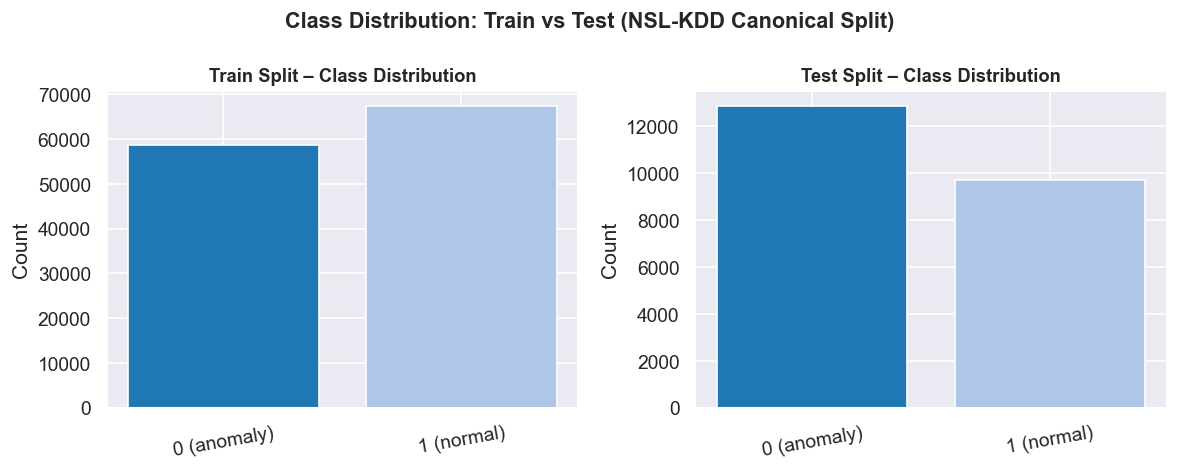

In [31]:
# ── Class balance by split ────────────────────────────────────────────────
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

tick_labels = [f'{i} ({class_names[i]})' for i in train_counts.index]
colors      = plt.cm.tab20.colors

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), dpi=120)
ax1.bar(range(len(train_counts)), train_counts.values, color=colors[:n_classes])
ax1.set_title('Train Split – Class Distribution', fontsize=11, fontweight='bold')
ax1.set_xticks(range(len(train_counts)))
ax1.set_xticklabels(tick_labels, rotation=10)
ax1.set_ylabel('Count')

ax2.bar(range(len(test_counts)), test_counts.values, color=colors[:n_classes])
ax2.set_title('Test Split – Class Distribution', fontsize=11, fontweight='bold')
ax2.set_xticks(range(len(test_counts)))
ax2.set_xticklabels(tick_labels, rotation=10)
ax2.set_ylabel('Count')

plt.suptitle('Class Distribution: Train vs Test (NSL-KDD Canonical Split)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/fig_07_split_dist.png', dpi=120, bbox_inches='tight')
plt.show()

## 2 · Random Forest Feature Selection

In [32]:
selected_features, importances, rf_selector = select_features_rf(
    X_train, y_train,
    feature_names=feature_names,
    n_features=N_FEATURES,
    n_estimators=RF_ESTIMATORS,
    random_state=RANDOM_STATE,
)

print(f'Selected {len(selected_features)} features:')
for i, f in enumerate(selected_features, 1):
    print(f'  {i:2d}. {f}')

[feature_selection] Training Random Forest with 100 trees …
[feature_selection] Top 20 features selected:
                    feature  importance
                    flag_SF    0.078812
              same_srv_rate    0.071958
         dst_host_srv_count    0.071081
              diff_srv_rate    0.057737
     dst_host_same_srv_rate    0.056578
                      count    0.055970
                  logged_in    0.044497
   dst_host_srv_serror_rate    0.043837
         protocol_type_icmp    0.037838
       dst_host_serror_rate    0.037436
     dst_host_diff_srv_rate    0.037415
dst_host_same_src_port_rate    0.032157
                    flag_S0    0.030346
            srv_serror_rate    0.030144
            service_private    0.025649
               service_http    0.025355
dst_host_srv_diff_host_rate    0.024256
             dst_host_count    0.020548
                rerror_rate    0.016029
       dst_host_rerror_rate    0.015569
Selected 20 features:
   1. flag_SF
   2. same_srv_rat

## 3 · Visualize Feature Importances

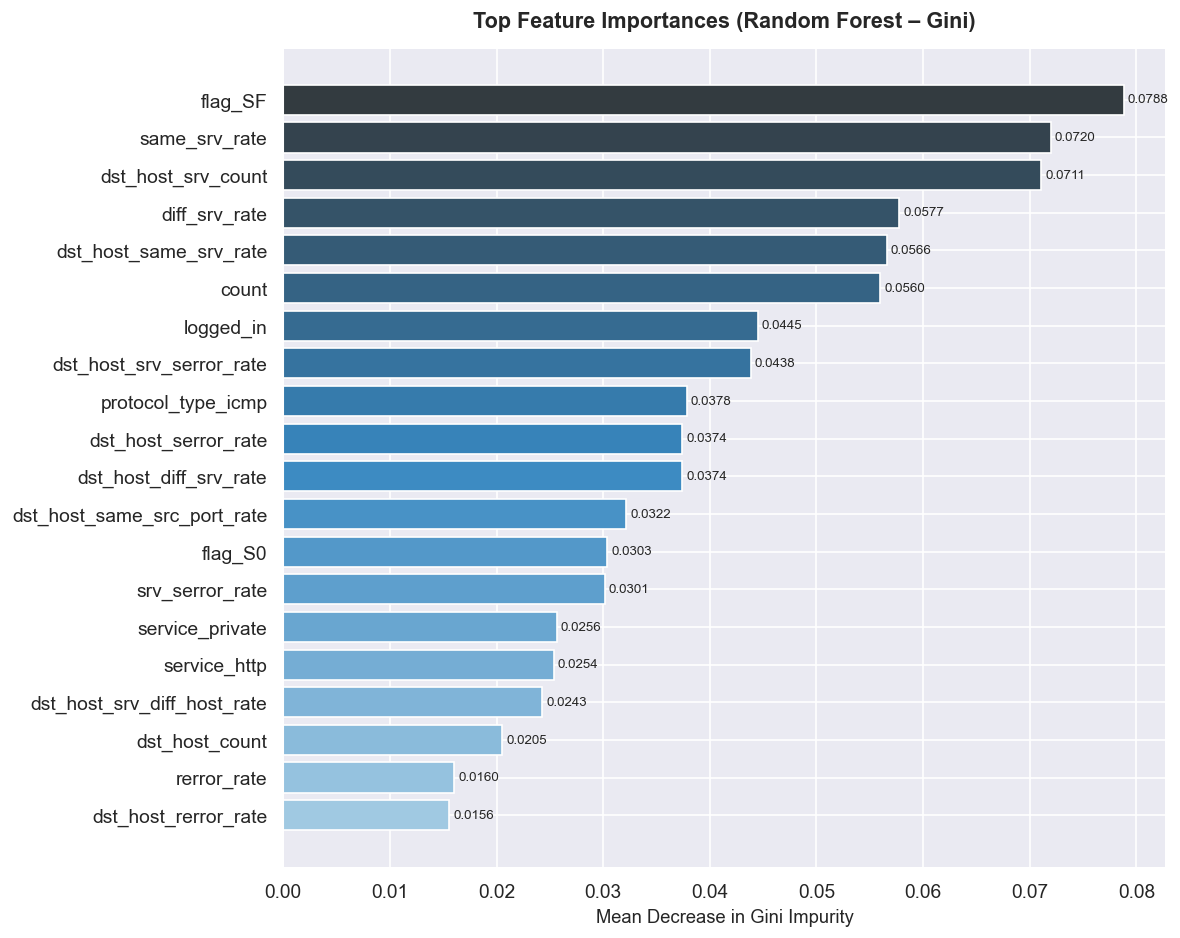

In [33]:
# All features – top highlighted
fig = plot_feature_importance(importances, n_features=N_FEATURES)
fig.savefig(f'{OUTPUT_DIR}/fig_08_top_feature_importances.png', dpi=120, bbox_inches='tight')
plt.show()

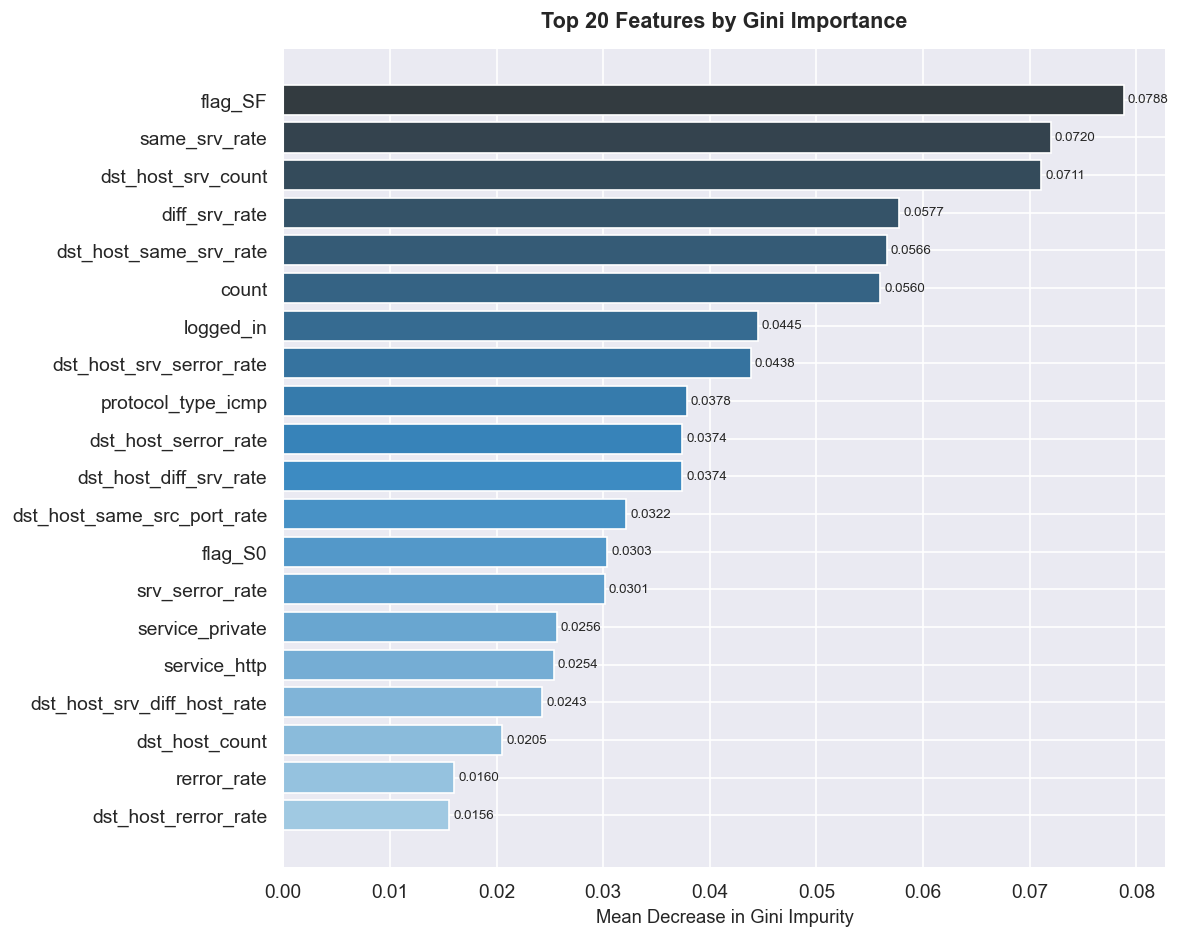

In [34]:
# Top-20 features detailed view
fig = plot_feature_importance(importances, n_features=N_FEATURES,
                               title=f'Top {N_FEATURES} Features by Gini Importance')
fig.savefig(f'{OUTPUT_DIR}/fig_09_all_feature_importances.png', dpi=120, bbox_inches='tight')
plt.show()

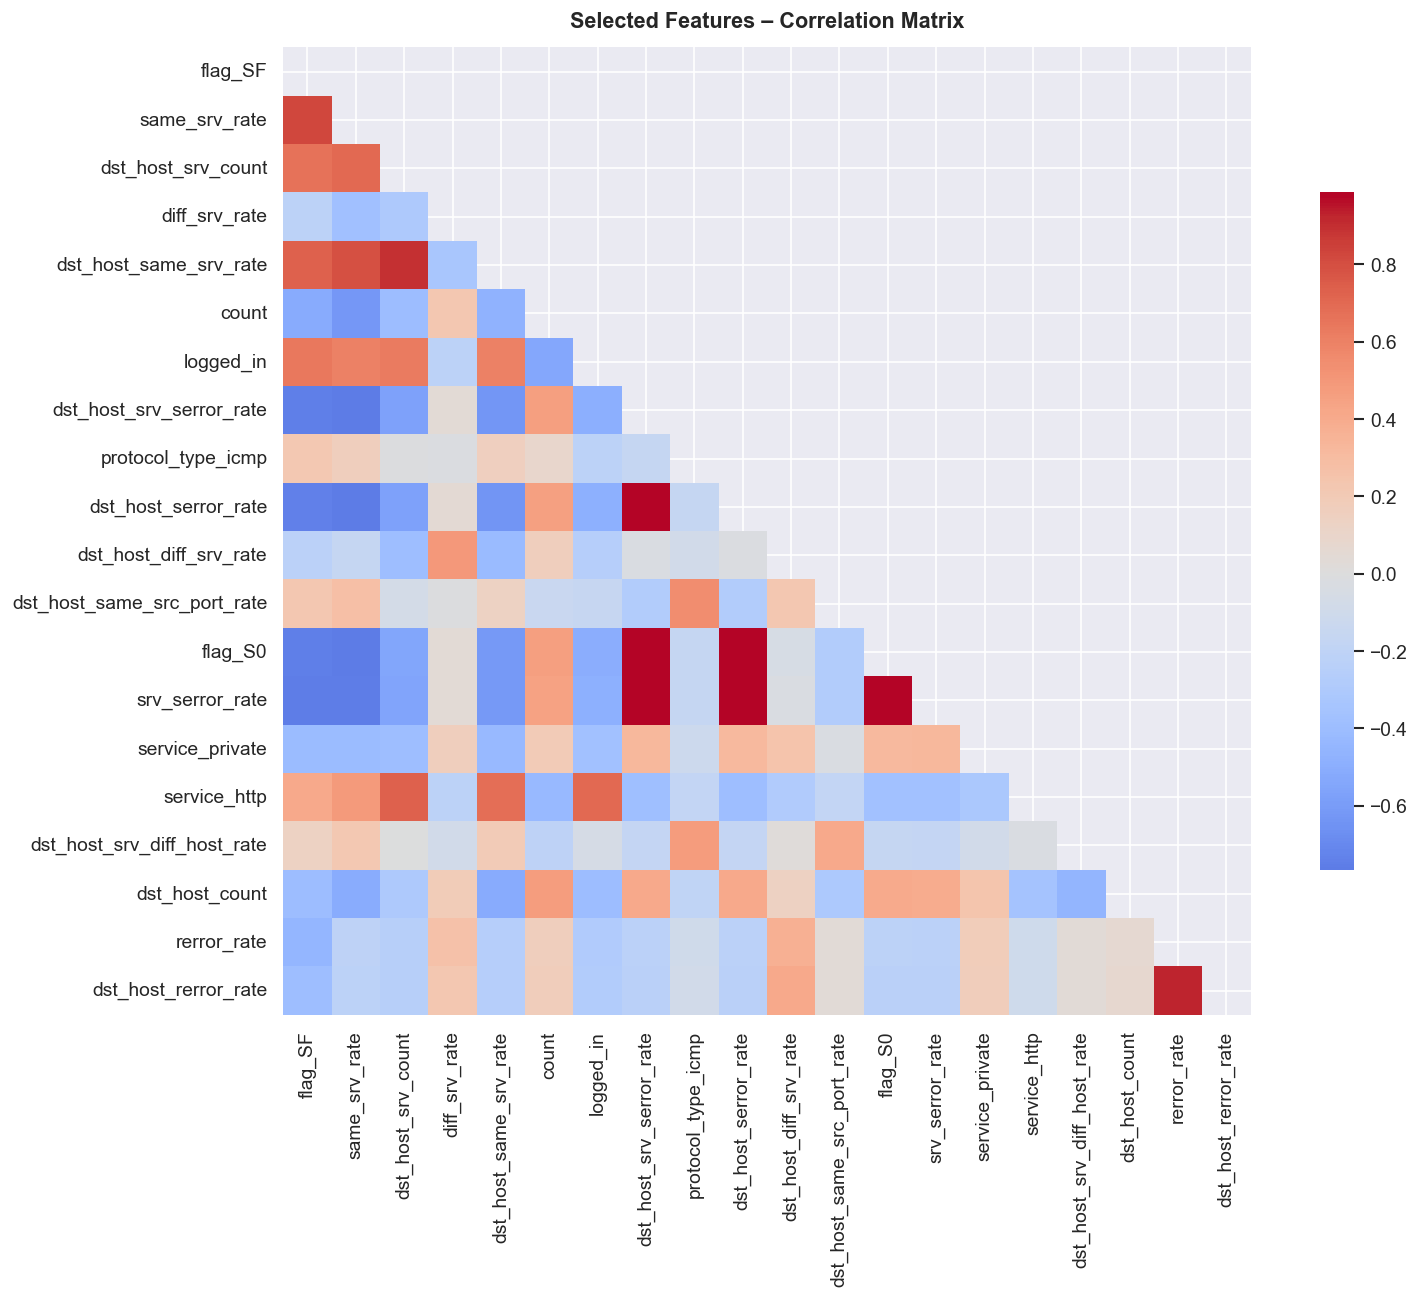

In [35]:
# Reduce X to selected features for heatmap
sel_idx     = [feature_names.index(f) for f in selected_features]
X_train_sel = X_train[:, sel_idx]
X_test_sel  = X_test[:, sel_idx]

df_sel = pd.DataFrame(X_train_sel, columns=selected_features)
fig = plot_correlation_heatmap(
    df_sel,
    title='Selected Features – Correlation Matrix',
)
fig.savefig(f'{OUTPUT_DIR}/fig_10_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

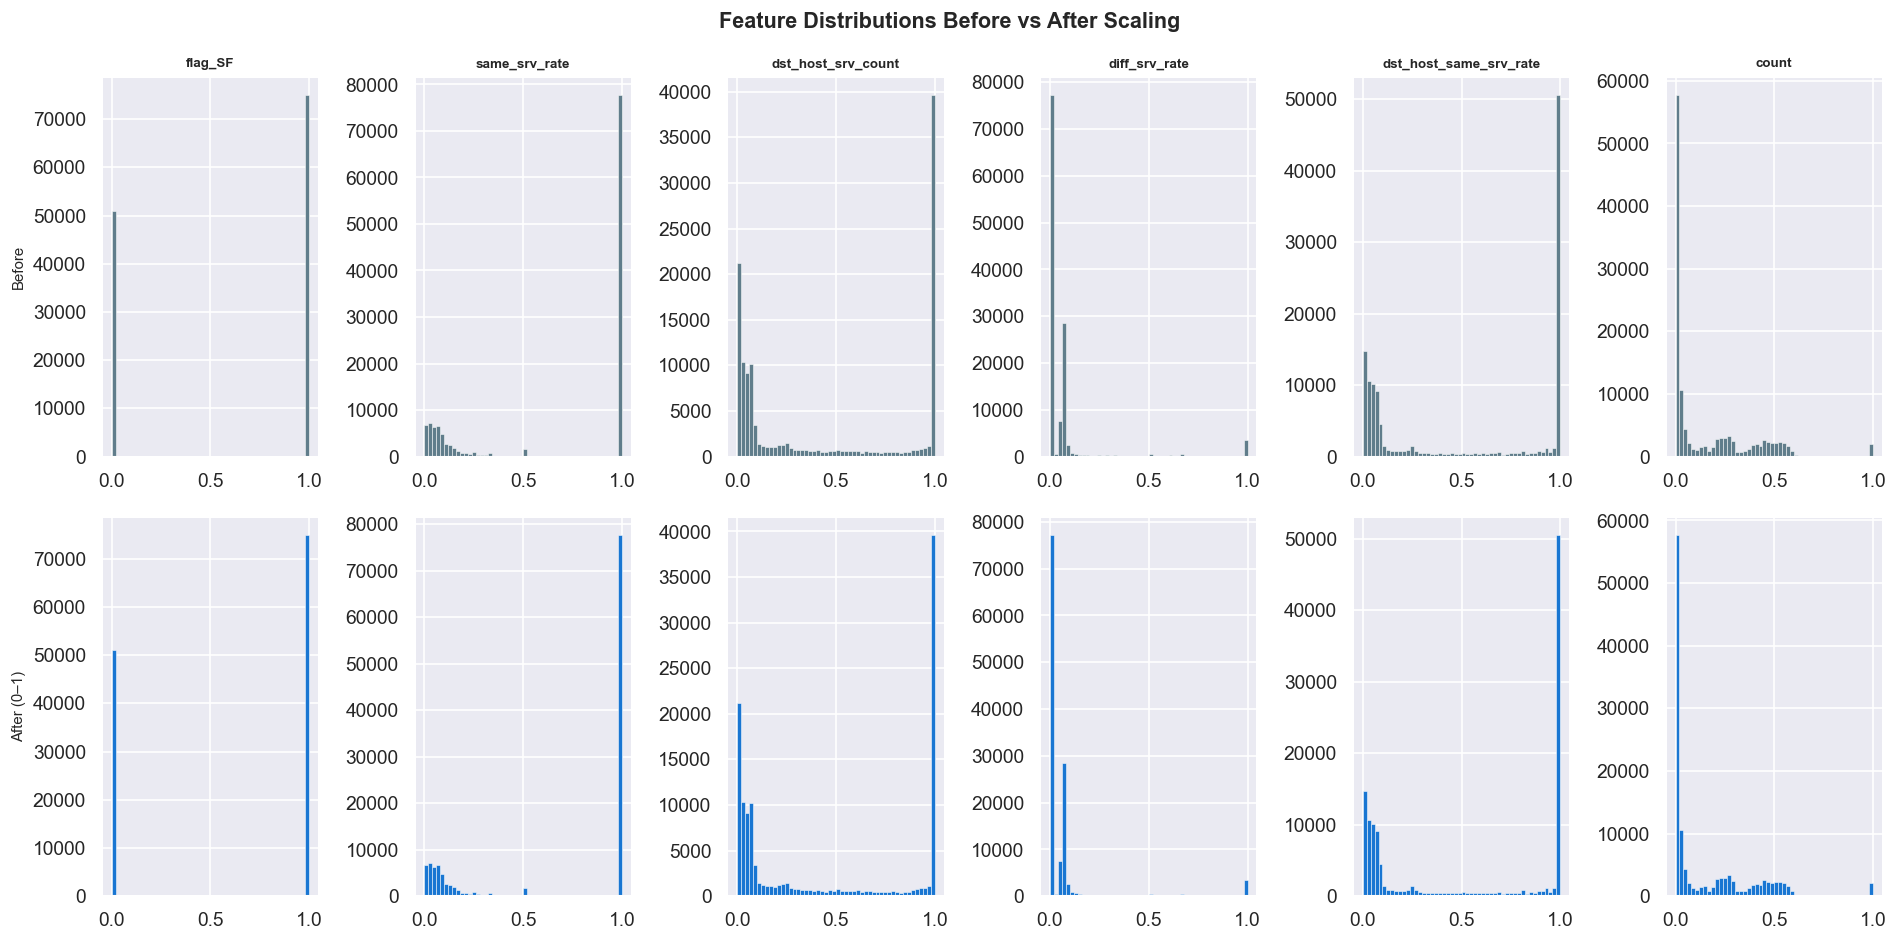

In [36]:
df_raw = pd.DataFrame(X_train[:, sel_idx], columns=selected_features)
fig = plot_feature_distributions(
    X_raw=df_raw,
    X_scaled=X_train_sel,
    feature_names=selected_features,
    n_features=min(6, len(selected_features)),
)
fig.savefig(f'{OUTPUT_DIR}/fig_11_feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

## 4 · Persist Selected Features & Updated Arrays

In [37]:
# Save reduced arrays
np.save(f'{OUTPUT_DIR}/X_train_sc.npy', X_train_sel)
np.save(f'{OUTPUT_DIR}/X_test_sc.npy',  X_test_sel)

# Save selected features list for the model dir (used at inference time)
save_selected_features(selected_features, f'{MODEL_DIR}/selected_features.json')

# Update metadata
meta['selected_features'] = selected_features
meta['n_features']        = len(selected_features)
with open(f'{OUTPUT_DIR}/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'✓ X_train_sc.npy updated  → {X_train_sel.shape}')
print(f'✓ X_test_sc.npy  updated  → {X_test_sel.shape}')
print(f'✓ selected_features.json  → {MODEL_DIR}/selected_features.json')
print(f'✓ metadata.json  updated  → {OUTPUT_DIR}/metadata.json')
print()
print('✓ Notebook 02 complete. Proceed to Notebook 03.')

[feature_selection] Selected features saved → ../../model/nsl-kdd/selected_features.json
✓ X_train_sc.npy updated  → (125973, 20)
✓ X_test_sc.npy  updated  → (22544, 20)
✓ selected_features.json  → ../../model/nsl-kdd/selected_features.json
✓ metadata.json  updated  → ../../data/processed-nslkdd/metadata.json

✓ Notebook 02 complete. Proceed to Notebook 03.
